<a href="https://colab.research.google.com/github/melyhorman/melyhorman.github.io/blob/main/Salinan_dari_Salinan_dari_VI_Revou_X_TELKOM_OCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagian Baru

#1 . Connect to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2 . Load File

In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(
    '/content/drive/MyDrive/FEB26_FSDANEXT_Bellatrix/FINAL CLIENT SEGMENTATION w channel.csv',
    sep=';'
)


In [4]:
df.head()

,user_id,user_name,total_transactions,total_revenue,engagement_rate_pct,success_rate_pct,total_channels_used,favorite_channel,final_segment
0,user_3,CV Wisata Indo,24635,5207360,37.91,79.57,4,WhatsApp,High Value Client
1,user_2,PT Dana Nusantara,24518,5198910,38.54,79.87,4,WhatsApp,High Value Client
2,user_1,CV Land Sejahtera,24496,5125530,38.67,79.32,4,WhatsApp,High Value Client
3,user_4,PT Konektivitas Indo,6230,1276070,38.25,78.88,4,WhatsApp,Core Operational Client
4,user_5,PT Karya Sejahtera,6198,1310570,38.33,79.27,4,WhatsApp,Core Operational Client


In [5]:
print(df)

    user_id             user_name  total_transactions  total_revenue  \
0    user_3        CV Wisata Indo               24635        5207360   
1    user_2     PT Dana Nusantara               24518        5198910   
2    user_1     CV Land Sejahtera               24496        5125530   
3    user_4  PT Konektivitas Indo                6230        1276070   
4    user_5    PT Karya Sejahtera                6198        1310570   
5    user_7   PT Retail Sejahtera                6132        1327690   
6    user_8  PT Belajar Nusantara                6117        1284620   
7    user_6   PT Logistik Mandiri                6010        1294970   
8   user_16   PT Estate Sejahtera                1593         339010   
9   user_18      CV Jalan Mandiri                1573         344080   
10  user_11   PT Travel Nusantara                1559         340730   
11  user_20         CV Hotel Jaya                1554         342240   
12  user_19         CV Niaga Indo                1552         33

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.columns

Index(['user_id', 'user_name', 'total_transactions', 'total_revenue',
       'engagement_rate_pct', 'success_rate_pct', 'total_channels_used',
       'favorite_channel', 'final_segment'],
      dtype='object')

#3 . Data Inspection

In [8]:
df.dtypes

,0
user_id,object
user_name,object
total_transactions,int64
total_revenue,int64
engagement_rate_pct,float64
success_rate_pct,float64
total_channels_used,int64
favorite_channel,object
final_segment,object


In [9]:
numeric_cols_thousands_separator = [
    'total_transactions',
    'total_revenue'
]

numeric_cols_percentage = [
    'engagement_rate_pct',
    'success_rate_pct'
]

for col in numeric_cols_thousands_separator:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False) # Remove thousands separator
        .astype(float)
    )

for col in numeric_cols_percentage:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False) # Remove percentage sign
        .str.replace(',', '.', regex=False) # Replace comma decimal with dot decimal
        .astype(float)
    )

In [10]:
# Sanity Check
df.dtypes

,0
user_id,object
user_name,object
total_transactions,float64
total_revenue,float64
engagement_rate_pct,float64
success_rate_pct,float64
total_channels_used,int64
favorite_channel,object
final_segment,object


#4 . Feature Selection

In [11]:
features = df[[
    'total_transactions',
    'total_revenue',
    'engagement_rate_pct',
    'success_rate_pct'
]]

#5 . Standardization

In [12]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

#6  . Elbow Method

In [13]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_features)

    inertia.append(km.inertia_)

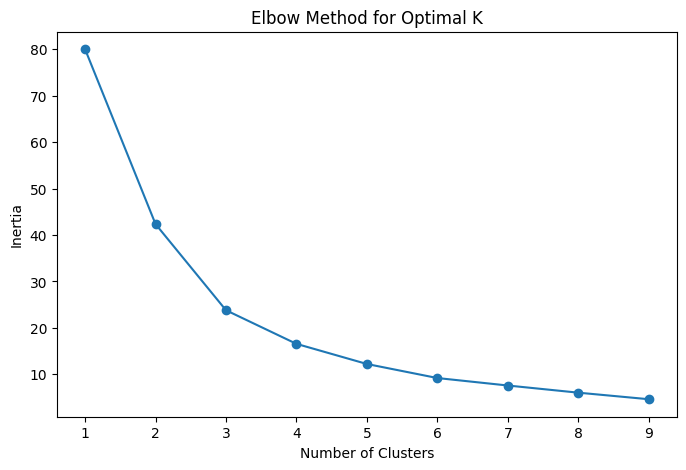

In [14]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

#7 . Kmeans Clustering

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10

)

df['cluster'] = kmeans.fit_predict(scaled_features)
df[['user_name', 'final_segment', 'cluster']]

,user_name,final_segment,cluster
0,CV Wisata Indo,High Value Client,0
1,PT Dana Nusantara,High Value Client,0
2,CV Land Sejahtera,High Value Client,0
3,PT Konektivitas Indo,Core Operational Client,2
4,PT Karya Sejahtera,Core Operational Client,2
5,PT Retail Sejahtera,Core Operational Client,1
6,PT Belajar Nusantara,Core Operational Client,2
7,PT Logistik Mandiri,Core Operational Client,2
8,PT Estate Sejahtera,Low Activity Client,1
9,CV Jalan Mandiri,Low Activity Client,1


In [16]:
df.to_csv('final_client_segmentation.csv', index=False)

Rule-based segmentation was validated using KMeans clustering to identify natural behavioral grouping patterns among enterprise clients.

#8  .Silhouette Score

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
score = silhouette_score(scaled_features, df['cluster'])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.409


#7 . Visualization

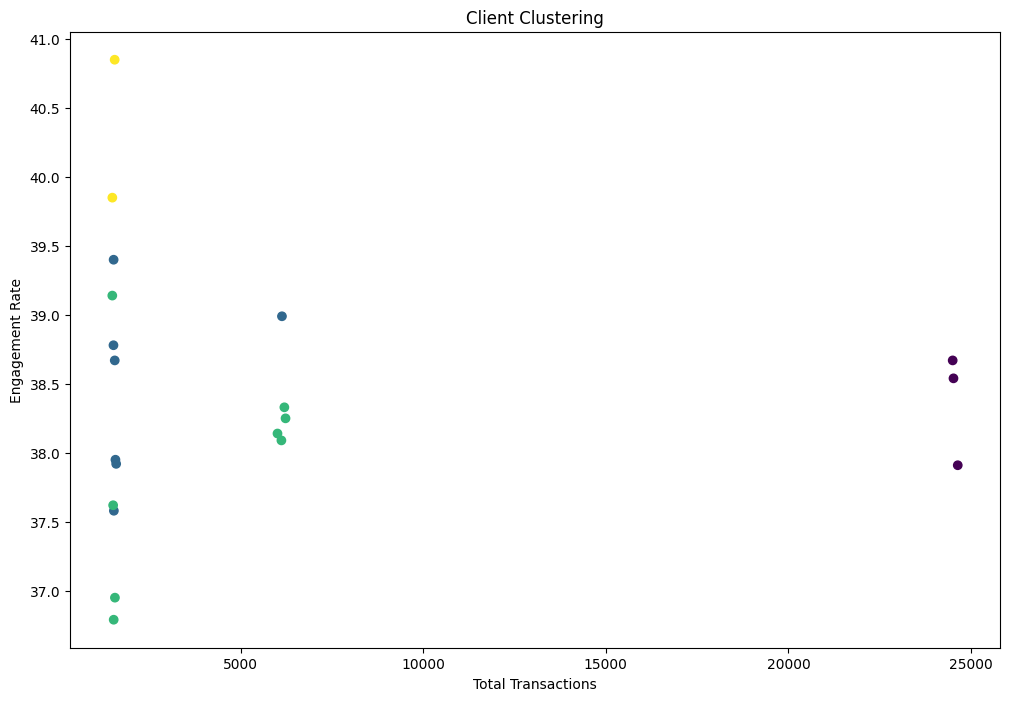

In [19]:
plt.figure(figsize=(12,8))

plt.scatter(
    df['total_transactions'],
    df['engagement_rate_pct'],
    c=df['cluster']
)

plt.xlabel('Total Transactions')
plt.ylabel('Engagement Rate')
plt.title('Client Clustering')

plt.show()

Behavioral clusters remain highly aligned with rule-based segmentation outputs, indicating stable user activity patterns across enterprise clients.
Behavioral clustering validation confirms similar operational patterns across high-value, retention-risk, and low-activity client groups.

In [20]:
#PCA VISUALIZATION
from sklearn.decomposition import PCA

# Reduce dimension
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_features,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = df['cluster']
pca_df['user_name'] = df['user_name']

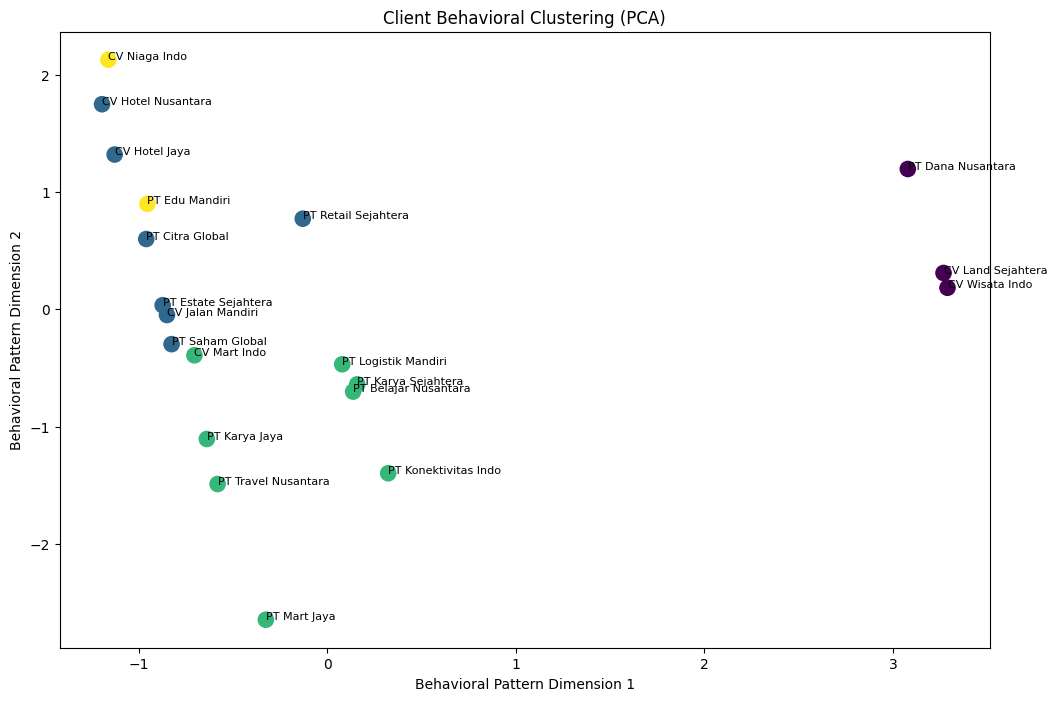

In [21]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
    s=120
)

for i, txt in enumerate(pca_df['user_name']):
    plt.annotate(
        txt,
        (pca_df['PC1'][i], pca_df['PC2'][i]),
        fontsize=8
    )

plt.title('Client Behavioral Clustering (PCA)')

plt.xlabel('Behavioral Pattern Dimension 1')
plt.ylabel('Behavioral Pattern Dimension 2')

plt.show()

#9 . Cluster Intrepretation

In [22]:
df.groupby('cluster')[[
    'total_transactions',
    'total_revenue',
    'engagement_rate_pct',
    'success_rate_pct'
]].mean()

,total_transactions,total_revenue,engagement_rate_pct,success_rate_pct
cluster,,,,
0,24549.666667,5.177267e+06,38.373333,79.586667
1,2203.428571,4.731957e+05,38.470000,79.974286
2,3829.500000,8.059000e+05,37.913750,79.231250
3,1520.000000,3.275250e+05,40.350000,79.700000


In [23]:
THANK YOU

SyntaxError: invalid syntax (482129816.py, line 1)